In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex', 'grid'])
from pathlib import Path

from Models import (
    DeletionImputer,
    ZeroImputer,
    EMImputer,
    KNNImputer,
    MahalanobisKNNImputer,
    BRITSImputer,
    CSDIImputer,
)
from Evaluations import Evaluator

In [12]:
seed = 69
rng = np.random.default_rng(seed)
FIG_DIR = Path("/Users/michelefanelli/Documents/Thesis/Latex/Figures")
FIG_DIR.mkdir(exist_ok=True)

## Data

`df` is the complete log-return panel (the ground truth). `Sparses`, `Gaps` and
`Stressed` hold copies of that panel with artificial missing values injected at
several intensities — each is a dict mapping the corruption level to a frame.

In [13]:
df = pd.read_csv("Data/log_returns.csv", index_col=0, parse_dates=True)


def load_corrupted(name):
    """Load every CSV in Data/<name>/ as a dict keyed by file stem."""
    base = Path("Data") / name
    return {
        f.stem: pd.read_csv(f, index_col=0, parse_dates=True)
        for f in sorted(base.glob("*.csv"))
    }


Sparses = load_corrupted("Sparses")
Gaps = load_corrupted("Gaps")
Stressed = load_corrupted("Stressed")

print("full panel:", df.shape)
print("Sparses :", list(Sparses))
print("Gaps    :", list(Gaps))
print("Stressed:", list(Stressed))

full panel: (4125, 50)
Sparses : ['0.001', '0.01', '0.05', '0.1', '0.3']
Gaps    : ['(1000, 10)', '(1000, 20)', '(20, 10)', '(200, 10)', '(2000, 30)']
Stressed: ['(0, 0.1, 0.99)', '(0.005, 0.5, 0.99)', '(0.04, 0.2, 0.95)', '(0.05, 0.5, 0.9)', '(0.2, 1, 0.9)']


## Imputers

Each imputer in `Models.py` shares the same interface — `fit`, `transform`,
`fit_transform` — taking a `(T, N)` panel with NaNs and returning a complete
panel with the observed cells left untouched (`DeletionImputer` is the
exception: it drops incomplete rows). The iterative models — `EMImputer`,
`BRITSImputer`, `CSDIImputer` — additionally record a `loss_history_` after
`fit` and accept `verbose=True`, so each can be trained on its own and watched
as it converges.

In [12]:
# The panel we'll work on (swap in any frame from Sparses / Gaps / Stressed).
panel = Sparses["0.05"]
print(f"panel: shape={panel.shape}, missing cells={int(panel.isna().sum().sum())}")

panel: shape=(4125, 50), missing cells=10409


## Train each model separately and watch it converge

We fit the iterative models one at a time with `verbose=True`. Each keeps a
per-iteration `loss_history_` (plotted together below). `epochs` is the main
speed/quality knob for the two neural models.

In [13]:
# EM's "loss" is the relative change in the estimated covariance per iteration --
# the parameter that actually drives the imputation -- which falls toward the
# tolerance over a handful of iterations. (Tracking the mean instead would stop
# after one step, since log-return means are ~0 and barely move.)
em = EMImputer(max_iter=50, verbose=True)
em.fit(panel)

EM    iter   1/50  cov update 1.08e-01
EM    iter   2/50  cov update 5.26e-03
EM    iter   3/50  cov update 9.74e-04
EM    iter   4/50  cov update 2.28e-04
EM    iter   5/50  cov update 5.95e-05


In [15]:
# BRITS -- raise epochs for better fits.
brits = BRITSImputer(epochs=2000, random_state=seed, verbose=True)
brits.fit(panel)

BRITS epoch    1/2000  loss 434.07200
BRITS epoch  200/2000  loss 285.99959
BRITS epoch  400/2000  loss 276.51617
BRITS epoch  600/2000  loss 274.70162
BRITS epoch  800/2000  loss 270.53984
BRITS epoch 1000/2000  loss 265.01371
BRITS epoch 1200/2000  loss 260.08974
BRITS epoch 1400/2000  loss 257.69812
BRITS epoch 1600/2000  loss 258.49361
BRITS epoch 1800/2000  loss 255.47095
BRITS epoch 2000/2000  loss 255.74952


In [ ]:
# CSDI is the heaviest model. Three things make it actually converge on this data:
#  - many small OVERLAPPING windows (window=32, stride=16) -> enough gradient steps
#    per epoch to train, and a much smoother loss curve;
#  - a randomized conditioning ratio while training (handled inside Models.py), so
#    the sampler stays calibrated for the ~95%-observed regime seen at inference;
#  - the imputation is the MEDIAN of n_samples reverse-diffusion draws -- a single
#    draw is very noisy on near-i.i.d. returns.
# Heavy on CPU (~5 min to train here, plus ~2 min to sample at n_samples=5); lower
# epochs / n_samples to trade quality for speed.
csdi = CSDIImputer(window=32, stride=8, epochs=5, n_samples=1,
                   random_state=seed, verbose=True)
csdi.fit(panel)

CSDI  epoch    1/5  loss 0.60101
CSDI  epoch    2/5  loss 0.42987
CSDI  epoch    3/5  loss 0.36165
CSDI  epoch    4/5  loss 0.38604
CSDI  epoch    5/5  loss 0.37573


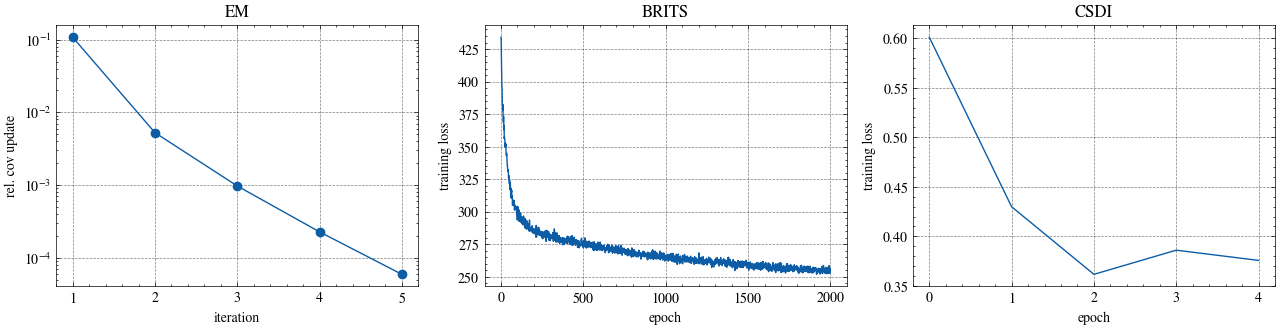

In [17]:
# Convergence curves. EM's metric is on a very different scale, so it gets its
# own (log-scale) panel.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].semilogy(range(1, len(em.loss_history_) + 1), em.loss_history_, marker="o")
axes[0].set(title="EM", xlabel="iteration", ylabel="rel. cov update")
axes[1].plot(brits.loss_history_)
axes[1].set(title="BRITS", xlabel="epoch", ylabel="training loss")
axes[2].plot(csdi.loss_history_)
axes[2].set(title="CSDI", xlabel="epoch", ylabel="training loss")
fig.tight_layout()
plt.show()

## Checkpoint & resume

The neural models store their weights **and** optimizer state, so a kernel restart
needn't mean retraining. `model.save(path)` pickles a fitted imputer and
`BRITSImputer.load(path)` brings it back. Set `warm_start=True` and a later `fit`
continues from the stored weights instead of starting over — `len(model.loss_history_)`
is the running epoch count. (`KNN`/`EM` save too, but having no weights there's
nothing to resume.)

In [ ]:
# Persist the models trained above (save() creates the folder if needed).
CKPT = Path("Checkpoints")
em.save(CKPT / "em.pkl")
brits.save(CKPT / "brits.pkl")
csdi.save(CKPT / "csdi.pkl")

# In a fresh kernel, reload instead of retraining:
brits = BRITSImputer.load(CKPT / "brits.pkl")

# ...and continue training from where it stopped: warm_start resumes the stored
# weights + optimizer, so these epochs add on top (a plain fit would start over).
brits.warm_start = True
brits.epochs = 200
brits.fit(panel)
brits.save(CKPT / "brits.pkl")
print("BRITS epochs trained so far:", len(brits.loss_history_))

## Reconstruct & compare

With the models trained, fill the panel with each and overlay the results on a
single asset as a sanity check. (Quantitative evaluation against `df` comes
later.)

In [18]:
# Assemble every reconstruction: the instant imputers via fit_transform, the
# already-trained ones via transform (no retraining).
reconstructed = {
    "Deletion": DeletionImputer().fit_transform(panel),
    "Zero":     ZeroImputer().fit_transform(panel),
    "KNN":      KNNImputer(n_neighbors=5, weights="distance").fit_transform(panel),
    "MahaKNN":  MahalanobisKNNImputer(n_neighbors=5, weights="distance").fit_transform(panel),
    "EM":       em.transform(panel),
    "BRITS":    brits.transform(panel),
    "CSDI":     csdi.transform(panel),
}
for name, Xi in reconstructed.items():
    Xi = np.asarray(Xi)
    note = "full panel" if Xi.shape == panel.shape else "rows dropped"
    print(f"{name:9s} -> {str(Xi.shape):12s} NaNs left={int(np.isnan(Xi).sum()):4d}  ({note})")

Deletion  -> (300, 50)    NaNs left=   0  (rows dropped)
Zero      -> (4125, 50)   NaNs left=   0  (full panel)
KNN       -> (4125, 50)   NaNs left=   0  (full panel)
MahaKNN   -> (4125, 50)   NaNs left=   0  (full panel)
EM        -> (4125, 50)   NaNs left=   0  (full panel)
BRITS     -> (4125, 50)   NaNs left=   0  (full panel)
CSDI      -> (4125, 50)   NaNs left=   0  (full panel)


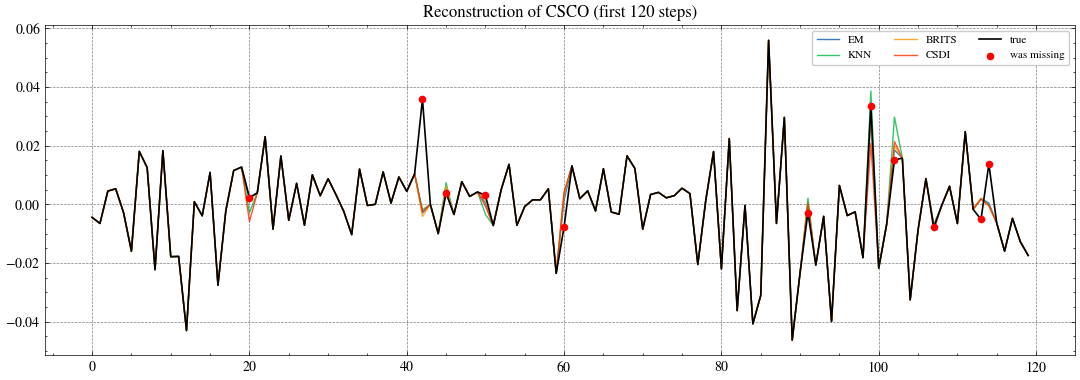

In [19]:

# Overlay one asset's reconstructions, with the originally-missing points in red.
asset, win = 3, 120
true = df.to_numpy()[:win, asset]
missing_idx = np.where(np.isnan(panel.to_numpy()[:win, asset]))[0]

plt.figure(figsize=(11, 4))
for name in ["EM", "KNN", "BRITS", "CSDI"]:
    plt.plot(np.asarray(reconstructed[name])[:win, asset], lw=1, alpha=0.8, label=name)
plt.plot(true, color="black", lw=1.2, label="true")
plt.scatter(missing_idx, true[missing_idx], color="red", s=20, zorder=5, label="was missing")
plt.legend(ncol=3, fontsize=8)
plt.title(f"Reconstruction of {df.columns[asset]} (first {win} steps)")
plt.tight_layout()
plt.show()

In [20]:
# True vs. reconstructed covariance matrix: relative Frobenius error (lower = better).
cov_true = np.cov(df.to_numpy(), rowvar=False)
cov_error = {
    name: np.linalg.norm(np.cov(np.asarray(Xi), rowvar=False) - cov_true) / np.linalg.norm(cov_true)
    for name, Xi in reconstructed.items()
}
pd.Series(cov_error, name="rel. cov error").sort_values()

BRITS       0.015031
EM          0.015133
KNN         0.028343
MahaKNN     0.052565
Zero        0.104353
Deletion    0.195070
CSDI        0.981881
Name: rel. cov error, dtype: float64

## Evaluation

Score every model on every missingness level with `Evaluations.py`. BRITS and CSDI are
checkpointed per panel under `Checkpoints/eval/`, and **rerunning the loop cell continues
their training from the stored weights** (the first run, with no `.pkl` yet, starts from
scratch) — so you can run → evaluate → run the loop again to train further → evaluate
again. The cheap imputers are fit per panel each time. MAE/RMSE are measured on the
originally-missing cells; the other metrics compare the full reconstructed panels against
the ground truth `df`.

In [10]:
EVAL_CKPT = Path("Checkpoints/eval")

def fit_or_load(model, panel, path):
    """Continue training from the stored checkpoint, or start fresh if there is
    none yet, then (re)save. So rerunning the loop trains further each time."""
    path = Path(path)
    if path.exists():
        model = type(model).load(path)   # reload stored weights + optimizer
        model.warm_start = True          # and keep training on top of them
    model.fit(panel)                     # cold the first time, resumes afterwards
    return model.save(path)


def impute_all(level, corrupted):
    """Reconstruct one panel with every model. Only BRITS and CSDI are checkpointed
    (one file per missingness level); the cheap imputers are just fit on the spot."""
    tag = "".join(c if c.isalnum() else "_" for c in level)   # filename-safe level
    brits = fit_or_load(BRITSImputer(epochs=10000, random_state=seed),
                        corrupted, EVAL_CKPT / f"brits_{tag}.pkl")
    csdi = fit_or_load(CSDIImputer(window=32, stride=8, epochs=2000, n_samples=32,
                                   random_state=seed),
                       corrupted, EVAL_CKPT / f"csdi_{tag}.pkl")
    return {
        "Deletion": DeletionImputer().fit_transform(corrupted),
        "Zero":     ZeroImputer().fit_transform(corrupted),
        "KNN":      KNNImputer(n_neighbors=5, weights="distance").fit_transform(corrupted),
        "MahaKNN":  MahalanobisKNNImputer(n_neighbors=5, weights="distance").fit_transform(corrupted),
        "EM":       EMImputer(max_iter=50).fit_transform(corrupted),
        "BRITS":    brits.transform(corrupted),
        "CSDI":     csdi.transform(corrupted),
    }


In [ ]:
# Pick the family to score; swap for Gaps / Stressed (or {**Sparses, **Gaps, **Stressed}).
# BRITS and CSDI checkpoint to Checkpoints/eval/ (one file per level). Each rerun of
# this cell CONTINUES their training from the stored weights; the first run (no .pkl
# yet) starts from scratch. Delete a file (or the folder) to restart that regime.
datasets = Gaps

runs, masks = {}, {}
for level, corrupted in datasets.items():
    print(f"[{level}] training & imputing ...")
    runs[level] = impute_all(level, corrupted)
    masks[level] = np.isnan(corrupted.to_numpy())

scores = Evaluator(var_level=0.05, sig_depth=2).evaluate_runs(runs, df, masks)
scores.round(4)

In [5]:
# Reload the checkpointed BRITS/CSDI from Checkpoints/eval (no training) and rebuild
# `runs`/`masks`, so Evaluator can be run again without retraining. Cheap imputers are
# re-fit on the spot as before.
EVAL_CKPT = Path("Checkpoints/eval")
datasets = Sparses

runs, masks = {}, {}
for level, corrupted in datasets.items():
    tag = "".join(c if c.isalnum() else "_" for c in level)   # filename-safe level
    brits = BRITSImputer.load(EVAL_CKPT / f"brits_{tag}.pkl")
    csdi = CSDIImputer.load(EVAL_CKPT / f"csdi_{tag}.pkl")
    runs[level] = {
        "Deletion": DeletionImputer().fit_transform(corrupted),
        "Zero":     ZeroImputer().fit_transform(corrupted),
        "KNN":      KNNImputer(n_neighbors=5, weights="distance").fit_transform(corrupted),
        "MahaKNN":  MahalanobisKNNImputer(n_neighbors=5, weights="distance").fit_transform(corrupted),
        "EM":       EMImputer(max_iter=50).fit_transform(corrupted),
        "BRITS":    brits.transform(corrupted),
        "CSDI":     csdi.transform(corrupted),
    }
    masks[level] = np.isnan(corrupted.to_numpy())
    print(f"[{level}] loaded from checkpoints")

scores = Evaluator(var_level=0.05, sig_depth=2).evaluate_runs(runs, df, masks)
scores.round(4)

[0.001] loaded from checkpoints
[0.01] loaded from checkpoints
[0.05] loaded from checkpoints
[0.1] loaded from checkpoints
[0.3] loaded from checkpoints


MAE    RMSE  CovErr  VolErr  VaR5Err  WassErr  SigErr
dataset model                                                             
0.001   Deletion     NaN     NaN  0.0119  0.0041   0.0001   0.0001  0.1557
        Zero      0.0118  0.0194  0.0026  0.0007   0.0000   0.0000  0.0210
        KNN       0.0099  0.0168  0.0018  0.0006   0.0000   0.0000  0.0176
        MahaKNN   0.0102  0.0173  0.0021  0.0006   0.0000   0.0000  0.0183
        EM        0.0080  0.0147  0.0015  0.0005   0.0000   0.0000  0.0171
        BRITS     0.0091  0.0158  0.0016  0.0005   0.0000   0.0000  0.0187
        CSDI      0.0078  0.0149  0.0016  0.0005   0.0000   0.0000  0.0163
0.01    Deletion     NaN     NaN  0.0532  0.0179   0.0005   0.0004  0.3482
        Zero      0.0107  0.0161  0.0205  0.0049   0.0001   0.0001  0.0634
        KNN       0.0081  0.0123  0.0069  0.0031   0.0001   0.0000  0.0491
        MahaKNN   0.0090  0.0134  0.0125  0.0041   0.0001   0.0001  0.0558
        EM        0.0071  0.0109  0.0051  0.0023   0.0000   0.0000  0.0454
        BRITS     0.0076  0.0116  0.0064  0.0027   0.0001   0.0000  0.0470
        CSDI      0.0069  0.0108  0.0051  0.0022   0.0001   0.0000  0.0416
0.05    Deletion     NaN     NaN  0.1951  0.0540   0.0019   0.0012  0.9783
        Zero      0.0111  0.0167  0.1044  0.0263   0.0005   0.0006  0.1688
        KNN       0.0084  0.0127  0.0283  0.0168   0.0003   0.0002  0.1216
        MahaKNN   0.0089  0.0134  0.0526  0.0208   0.0004   0.0003  0.1322
        EM        0.0072  0.0113  0.0151  0.0120   0.0002   0.0002  0.1167
        BRITS     0.0073  0.0113  0.0145  0.0120   0.0002   0.0002  0.1141
        CSDI      0.0072  0.0112  0.0154  0.0108   0.0002   0.0002  0.1383
0.1     Deletion     NaN     NaN  0.4492  0.2234   0.0091   0.0051  0.9836
        Zero      0.0109  0.0163  0.1872  0.0504   0.0011   0.0011  0.2197
        KNN       0.0083  0.0125  0.0487  0.0317   0.0007   0.0004  0.1949
        MahaKNN   0.0086  0.0130  0.0789  0.0376   0.0008   0.0005  0.1969
        EM        0.0071  0.0110  0.0237  0.0220   0.0005   0.0003  0.1559
        BRITS     0.0072  0.0111  0.0238  0.0211   0.0005   0.0003  0.1502
        CSDI      0.0072  0.0111  0.0265  0.0197   0.0004   0.0003  0.1966
0.3     Deletion     NaN     NaN     NaN     NaN      NaN      NaN     NaN
        Zero      0.0109  0.0161  0.4749  0.1605   0.0037   0.0033  0.4614
        KNN       0.0087  0.0129  0.1467  0.1055   0.0024   0.0014  0.3524
        MahaKNN   0.0087  0.0129  0.1670  0.1104   0.0025   0.0015  0.3727
        EM        0.0074  0.0112  0.0565  0.0730   0.0017   0.0009  0.2972
        BRITS     0.0076  0.0114  0.0536  0.0653   0.0015   0.0008  0.3063
        CSDI      0.0074  0.0113  0.0650  0.0641   0.0015   0.0008  0.4228

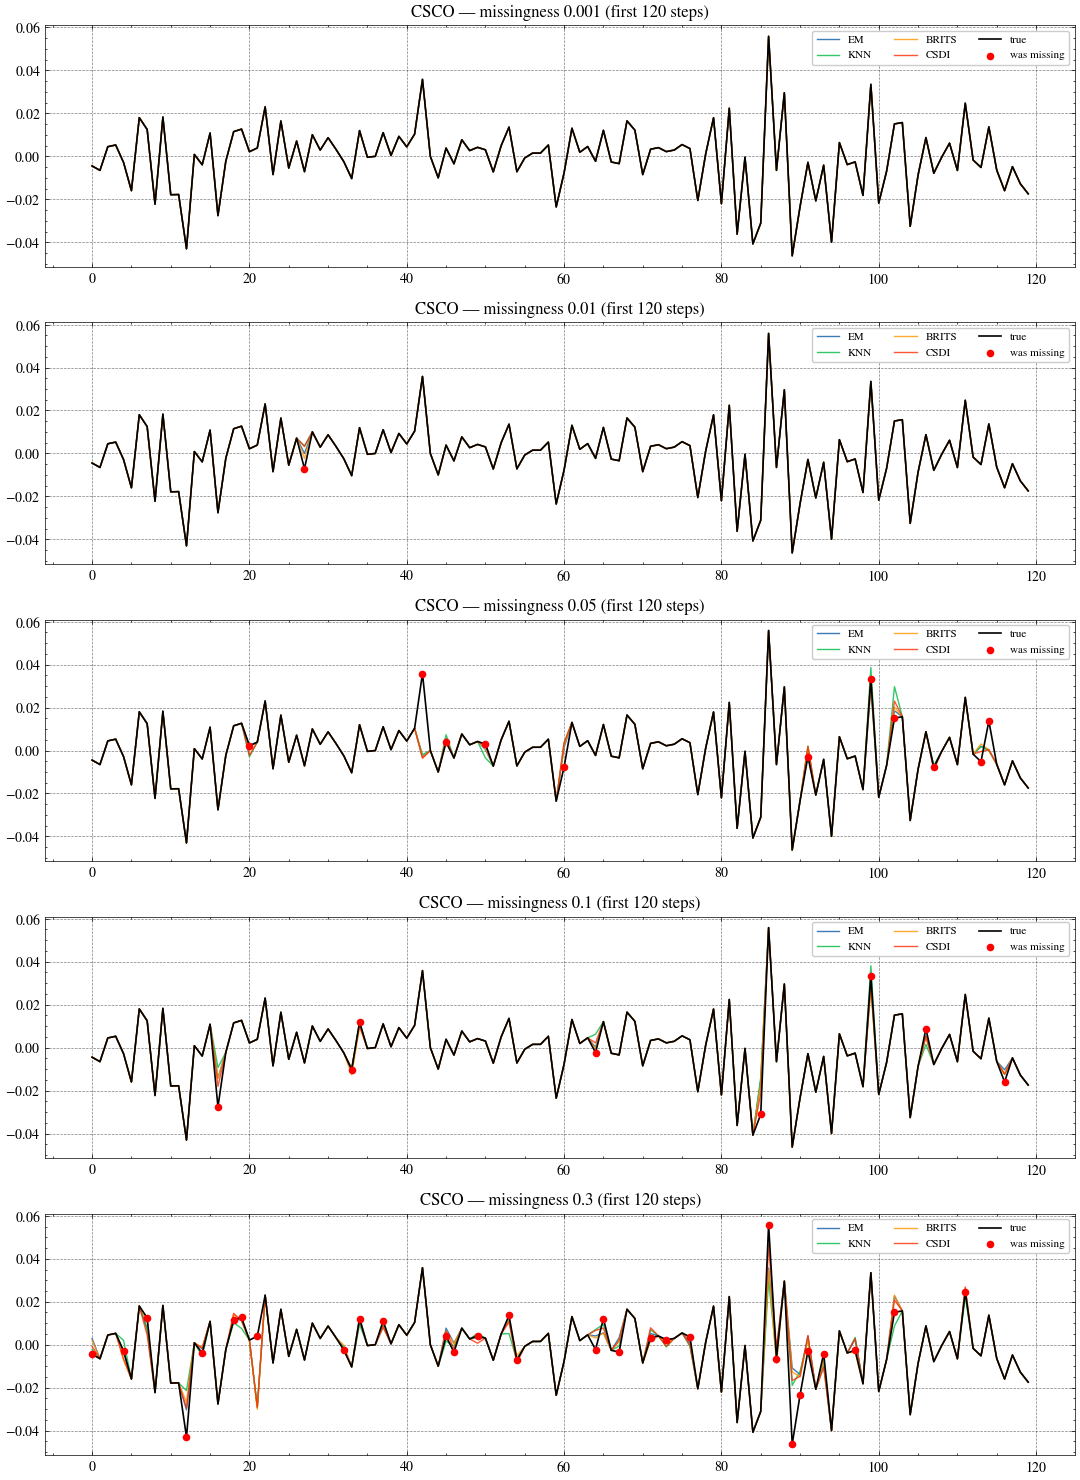

In [8]:
# Plot example reconstructions from the latest `runs` / `masks`. One row per
# missingness level, overlaying a few models on a single asset with the
# originally-missing points marked in red. (Deletion drops rows, so it's skipped.)
asset, win = 3, 120
show_models = ["EM", "KNN", "BRITS", "CSDI"]
true = df.to_numpy()[:win, asset]

levels = list(runs)
fig, axes = plt.subplots(len(levels), 1, figsize=(11, 3 * len(levels)), squeeze=False)
for ax, level in zip(axes[:, 0], levels):
    missing_idx = np.where(masks[level][:win, asset])[0]
    for name in show_models:
        ax.plot(np.asarray(runs[level][name])[:win, asset], lw=1, alpha=0.8, label=name)
    ax.plot(true, color="black", lw=1.2, label="true")
    ax.scatter(missing_idx, true[missing_idx], color="red", s=20, zorder=5, label="was missing")
    ax.set_title(f"{df.columns[asset]} — missingness {level} (first {win} steps)")
    ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

In [9]:
# Ensemble: average the reconstructions of every full-panel method (Deletion drops
# rows, so it's excluded). Add it to a fresh copy of `runs` and score everything.
runs_ens = {}
for level, models in runs.items():
    stack = [np.asarray(Xi) for Xi in models.values() if np.asarray(Xi).shape == df.shape]
    runs_ens[level] = {**models, "Ensemble": np.mean(stack, axis=0)}

scores_ens = Evaluator(var_level=0.05, sig_depth=2).evaluate_runs(runs_ens, df, masks)
scores_ens.round(4)

MAE    RMSE  CovErr  VolErr  VaR5Err  WassErr  SigErr
dataset model                                                             
0.001   Deletion     NaN     NaN  0.0119  0.0041   0.0001   0.0001  0.1557
        Zero      0.0118  0.0194  0.0026  0.0007   0.0000   0.0000  0.0210
        KNN       0.0099  0.0168  0.0018  0.0006   0.0000   0.0000  0.0176
        MahaKNN   0.0102  0.0173  0.0021  0.0006   0.0000   0.0000  0.0183
        EM        0.0080  0.0147  0.0015  0.0005   0.0000   0.0000  0.0171
        BRITS     0.0091  0.0158  0.0016  0.0005   0.0000   0.0000  0.0187
        CSDI      0.0078  0.0149  0.0016  0.0005   0.0000   0.0000  0.0163
        Ensemble  0.0087  0.0159  0.0018  0.0006   0.0000   0.0000  0.0172
0.01    Deletion     NaN     NaN  0.0532  0.0179   0.0005   0.0004  0.3482
        Zero      0.0107  0.0161  0.0205  0.0049   0.0001   0.0001  0.0634
        KNN       0.0081  0.0123  0.0069  0.0031   0.0001   0.0000  0.0491
        MahaKNN   0.0090  0.0134  0.0125  0.0041   0.0001   0.0001  0.0558
        EM        0.0071  0.0109  0.0051  0.0023   0.0000   0.0000  0.0454
        BRITS     0.0076  0.0116  0.0064  0.0027   0.0001   0.0000  0.0470
        CSDI      0.0069  0.0108  0.0051  0.0022   0.0001   0.0000  0.0416
        Ensemble  0.0074  0.0116  0.0082  0.0037   0.0001   0.0001  0.0455
0.05    Deletion     NaN     NaN  0.1951  0.0540   0.0019   0.0012  0.9783
        Zero      0.0111  0.0167  0.1044  0.0263   0.0005   0.0006  0.1688
        KNN       0.0084  0.0127  0.0283  0.0168   0.0003   0.0002  0.1216
        MahaKNN   0.0089  0.0134  0.0526  0.0208   0.0004   0.0003  0.1322
        EM        0.0072  0.0113  0.0151  0.0120   0.0002   0.0002  0.1167
        BRITS     0.0073  0.0113  0.0145  0.0120   0.0002   0.0002  0.1141
        CSDI      0.0072  0.0112  0.0154  0.0108   0.0002   0.0002  0.1383
        Ensemble  0.0076  0.0118  0.0338  0.0191   0.0004   0.0003  0.1194
0.1     Deletion     NaN     NaN  0.4492  0.2234   0.0091   0.0051  0.9836
        Zero      0.0109  0.0163  0.1872  0.0504   0.0011   0.0011  0.2197
        KNN       0.0083  0.0125  0.0487  0.0317   0.0007   0.0004  0.1949
        MahaKNN   0.0086  0.0130  0.0789  0.0376   0.0008   0.0005  0.1969
        EM        0.0071  0.0110  0.0237  0.0220   0.0005   0.0003  0.1559
        BRITS     0.0072  0.0111  0.0238  0.0211   0.0005   0.0003  0.1502
        CSDI      0.0072  0.0111  0.0265  0.0197   0.0004   0.0003  0.1966
        Ensemble  0.0074  0.0115  0.0574  0.0357   0.0008   0.0005  0.1590
0.3     Deletion     NaN     NaN     NaN     NaN      NaN      NaN     NaN
        Zero      0.0109  0.0161  0.4749  0.1605   0.0037   0.0033  0.4614
        KNN       0.0087  0.0129  0.1467  0.1055   0.0024   0.0014  0.3524
        MahaKNN   0.0087  0.0129  0.1670  0.1104   0.0025   0.0015  0.3727
        EM        0.0074  0.0112  0.0565  0.0730   0.0017   0.0009  0.2972
        BRITS     0.0076  0.0114  0.0536  0.0653   0.0015   0.0008  0.3063
        CSDI      0.0074  0.0113  0.0650  0.0641   0.0015   0.0008  0.4228
        Ensemble  0.0077  0.0116  0.1498  0.1132   0.0027   0.0015  0.3014